In [ ]:
#Set the path to the assignment folder in GDrive
from google.colab import drive

try:
  drive.mount('/content/gdrive')
except:
  print("Load the drive manually from the left panel first. Then run this again,")
  pathBase="/content/drive/MyDrive/"

Mounted at /content/gdrive


In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("/content/gdrive/MyDrive/diabetes.csv")

# Checking dataset shape
print("Dataset shape:", df.shape)
print(df.head())
print(df.info())

# Separate the data columns into features(X) and labels(y)
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# feature count
feature_count = df.shape[1] - 1

# class count
class_count = df["Outcome"].nunique()

print(f"The dataset has {feature_count} features and {class_count} classes.")


# Split dataset into random train and test subsets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining set size: ", X_train.shape)
print("Test set size: ", X_test.shape)

Dataset shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Gluco

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# columns where 0 means missing value
missing_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# setting up some scaling methods for comparison
scaling_methods =  {
    "Standard": StandardScaler(),
    "MinMax": MinMaxScaler(),
    "Robust": RobustScaler()
}

def perform_scaling(scaler_name, scaler, X_train, X_test, y_train, y_test):
    # In this pipeline, firstly, fixing missing values
    # secondly, scaling all data and thirdly, training MLP
    model = Pipeline([
        ("fill_with_median", SimpleImputer(missing_values=0, strategy="median")),
        ("scale_data", scaler),
        ("mlp", MLPClassifier(hidden_layer_sizes=(100,50),
                              max_iter=1000, random_state=42))
    ])

    # fitting into training set
    model.fit(X_train, y_train)

    # making predictions on test set
    test_pred = model.predict(X_test)

    # calculate accuracy and outputs result
    test_accuracy = accuracy_score(y_test, test_pred)
    print(f"\n For {scaler_name} : ")
    print("Test Accuracy:", round(test_accuracy, 4))
    print(classification_report(y_test, test_pred, digits=4))

    return test_accuracy

# evaluation for scaling methods
scaling_outputs = {
    name: perform_scaling(name, scaler, X_train, X_test, y_train, y_test)
    for name, scaler in scaling_methods.items()
}

# outputs the summary and best scaler
print("\nSummary:", {name: round(scaling_outputs[name],4) for name in scaling_outputs})
best = max(scaling_outputs, key=scaling_outputs.get)
print("The best scaler is: ", best)



 For Standard : 
Test Accuracy: 0.6688
              precision    recall  f1-score   support

           0     0.7449    0.7374    0.7411        99
           1     0.5357    0.5455    0.5405        55

    accuracy                         0.6688       154
   macro avg     0.6403    0.6414    0.6408       154
weighted avg     0.6702    0.6688    0.6695       154


 For MinMax : 
Test Accuracy: 0.7662
              precision    recall  f1-score   support

           0     0.8058    0.8384    0.8218        99
           1     0.6863    0.6364    0.6604        55

    accuracy                         0.7662       154
   macro avg     0.7460    0.7374    0.7411       154
weighted avg     0.7631    0.7662    0.7641       154


 For Robust : 
Test Accuracy: 0.7273
              precision    recall  f1-score   support

           0     0.8000    0.7677    0.7835        99
           1     0.6102    0.6545    0.6316        55

    accuracy                         0.7273       154
   macro avg

In [ ]:
# Run MLP with different solver values
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# solver list for testing
solvers = ["lbfgs", "adam", "sgd"]

for solver in solvers:
    print(f"\n Evaluating MLP with solver = {solver} ")

    # In this pipeline, firstly, fixing missing values
    # secondly, scaling all data and thirdly, training MLP with solver

    classifier = Pipeline([
        ("fill_with_median", SimpleImputer(missing_values=0, strategy="median")),
        ("normalize", StandardScaler()),
        ("classifier", MLPClassifier(hidden_layer_sizes=(100, 50),
                                     solver=solver,
                                 max_iter=1000, random_state=42))
    ])

    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)

    # outputs accuracy
    print("\n Accuracy is:", accuracy_score(y_test, y_pred))
    # outputs classification report
    print(classification_report(y_test, y_pred))


 Evaluating MLP with solver = lbfgs 

 Accuracy is: 0.7012987012987013
              precision    recall  f1-score   support

           0       0.78      0.74      0.76        99
           1       0.57      0.64      0.60        55

    accuracy                           0.70       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.71      0.70      0.70       154


 Evaluating MLP with solver = adam 

 Accuracy is: 0.6688311688311688
              precision    recall  f1-score   support

           0       0.74      0.74      0.74        99
           1       0.54      0.55      0.54        55

    accuracy                           0.67       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.67      0.67      0.67       154


 Evaluating MLP with solver = sgd 

 Accuracy is: 0.7597402597402597
              precision    recall  f1-score   support

           0       0.80      0.83      0.82        99
           1       0.67 

In [ ]:
# Vary the alpha parameter of the Multi-layer perceptron


import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Separate features(X) and label(y)
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Try different alpha values
alphas = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
scores = {}


for a in alphas:
    # In this pipeline, firstly, fixing missing values
    # secondly, scaling all data and thirdly, training MLP with alpha values

    mlp = Pipeline([
        ("fill_with_median", SimpleImputer(missing_values=0, strategy="median")),
        ("normalize", StandardScaler()),
        ("classifier", MLPClassifier(hidden_layer_sizes=(100, 50),
                                     alpha=a, max_iter=1000, random_state=42))
    ])
    # fit into training data
    mlp.fit(X_train, y_train)

    # calculate accuracy on test data
    ac = accuracy_score(y_test, mlp.predict(X_test))

    # Saving accuracy result for this alpha value
    scores[a] = ac

# outputs result with best alpha
print("Alpha with Accuracy:", {a: round(s, 4) for a, s in scores.items()})

best_alpha = max(scores, key=scores.get)

print("Best alpha is:", best_alpha, "with accuracy value:", round(scores[best_alpha], 4))

Alpha with Accuracy: {1e-05: 0.7597, 0.0001: 0.7662, 0.001: 0.7403, 0.01: 0.7338, 0.1: 0.7078}
Best alpha is: 0.0001 with accuracy value: 0.7662


In [ ]:
#implement the classifiers and evalaute separately. For evaluation, use classificationreport functionality of sklearn

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Implementing MLP Classifier

# In each pipeline, firstly, fixing missing values
# secondly, scaling all data and thirdly, implementing classifiers

mlp = Pipeline([
    ("fill_with_median", SimpleImputer(missing_values=0, strategy="median")),
    ("normalize", StandardScaler()),
    ("classifier", MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42))
])

# fitting into training set
mlp.fit(X_train, y_train)

print("\n MLP Classifier result:\n")
print(classification_report(y_test, mlp.predict(X_test), digits=4))

# Implementing SVM Classifier
svm = Pipeline([
    ("fill_with_median", SimpleImputer(missing_values=0, strategy="median")),
    ("normalize", StandardScaler()),
    ("classifier", SVC(kernel="rbf", random_state=42))
])

# fitting into training set
svm.fit(X_train, y_train)

print("\n SVM Classifier result: \n")
print(classification_report(y_test, svm.predict(X_test), digits=4))

# Implementing Logistic Regression
lr = Pipeline([
    ("fill_with_median", SimpleImputer(missing_values=0, strategy="median")),
    ("normalize", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

lr.fit(X_train, y_train)

print("\n Logistic Regression result: \n")
print(classification_report(y_test, lr.predict(X_test), digits=4))



 MLP Classifier result:

              precision    recall  f1-score   support

           0     0.8137    0.8300    0.8218       100
           1     0.6731    0.6481    0.6604        54

    accuracy                         0.7662       154
   macro avg     0.7434    0.7391    0.7411       154
weighted avg     0.7644    0.7662    0.7652       154


 SVM Classifier result: 

              precision    recall  f1-score   support

           0     0.7818    0.8600    0.8190       100
           1     0.6818    0.5556    0.6122        54

    accuracy                         0.7532       154
   macro avg     0.7318    0.7078    0.7156       154
weighted avg     0.7468    0.7532    0.7465       154


 Logistic Regression result: 

              precision    recall  f1-score   support

           0     0.7547    0.8000    0.7767       100
           1     0.5833    0.5185    0.5490        54

    accuracy                         0.7013       154
   macro avg     0.6690    0.6593    0.6629

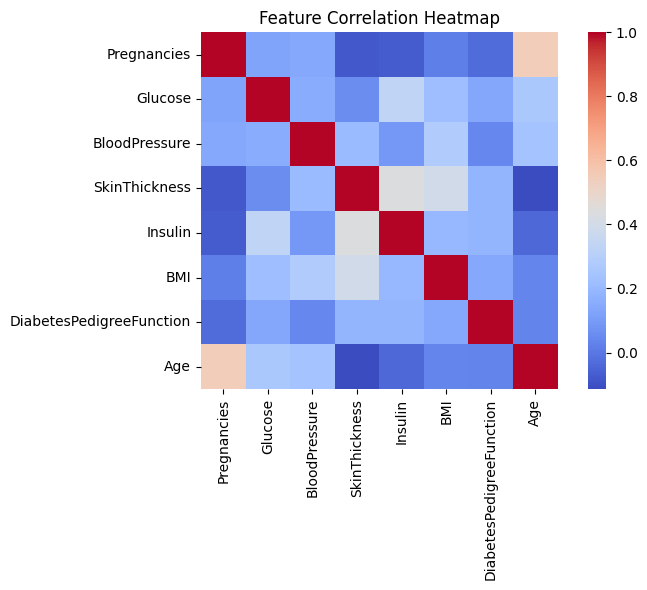


 Logistic Regression in baseline 

Accuracy: 0.7013
              precision    recall  f1-score   support

           0     0.7547    0.8000    0.7767       100
           1     0.5833    0.5185    0.5490        54

    accuracy                         0.7013       154
   macro avg     0.6690    0.6593    0.6629       154
weighted avg     0.6946    0.7013    0.6969       154


 PCA(95% variance) with LR is  

Accuracy: 0.7078
              precision    recall  f1-score   support

           0     0.7619    0.8000    0.7805       100
           1     0.5918    0.5370    0.5631        54

    accuracy                         0.7078       154
   macro avg     0.6769    0.6685    0.6718       154
weighted avg     0.7023    0.7078    0.7043       154


 FLD (LDA) with LR is 

Accuracy: 0.7013
              precision    recall  f1-score   support

           0     0.7500    0.8100    0.7788       100
           1     0.5870    0.5000    0.5400        54

    accuracy                        

0.7012987012987013

In [ ]:
# Feature Selection and Dimensionality Reduction
# Plot the correlation heatmap between the features
# Implement PCA and FLD dimensionality reduction methods
# Apply two feature selection techniques on the dataset

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Feature selection
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import RFE

# loading data
df = pd.read_csv("/content/gdrive/MyDrive/diabetes.csv")

# splitting training(80%) and test data(20%)
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# evaluating correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(numeric_only=True), annot=False, cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# training data and classification report

def run_and_report(name, pipe):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n {name} \n")
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_test, y_pred, digits=4))
    return acc

# Filling missing values and normalize

base_steps = [
    ("fill_with_median", SimpleImputer(missing_values=0, strategy="median")),
    ("normalize", StandardScaler())
]

# Logistic Regression in baseline

baseline = Pipeline(base_steps + [
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

run_and_report("Logistic Regression in baseline", baseline)

# Logistic Regression PCA(95% variance)

lr_pca = Pipeline(base_steps + [
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

run_and_report("PCA(95% variance) with LR is ", lr_pca)

# Logistic Regression LDA and for binary classes, LDA component reduction= 1

lr_lda = Pipeline(base_steps + [
    ("lda", LDA(n_components=1)),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])
run_and_report("FLD (LDA) with LR is", lr_lda)


# Feature Selection is kbest ANOVA F-test with LR, k=5

lr_skb = Pipeline(base_steps + [
    ("selectkbest", SelectKBest(score_func=f_classif, k=5)),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])
run_and_report("SelectKBest(k=5, f_classif) with LR", lr_skb)

# Feature Selection is RFE with LR

lr_rfe = Pipeline(base_steps + [
    ("rfe", RFE(estimator=LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=5)),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])
run_and_report("RFE(5 features, LR estimator) with LR", lr_rfe)